

# Project : HealthInsight – Healthcare Analytics & Predictive Insights

Hospital population analytics: condition prevalence, readmission risk prediction, risk tiers and an AI care-team summary. Uses made-up patient data only (not real patients, not medical advice).

## What this notebook does
- Makes 6000 made-up patient records (or uses your patients.csv with the same column names)
- Looks at conditions by age group and department
- Checks risk factors linked to 30-day readmission
- Trains Logistic Regression and Gradient Boosting, keeps the better one, and checks it with AUC and lift
- Puts patients into Low / Medium / High risk tiers
- Uses Groq AI to write a population health brief

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn openai

## Step 2: Connect to Groq (the AI part)
Paste your Groq API key when it asks. The key is hidden while you type.

In [2]:
import time
from getpass import getpass
from openai import OpenAI

GROQ_KEY = getpass("Paste your Groq API key: ")
client = OpenAI(api_key=GROQ_KEY, base_url="https://api.groq.com/openai/v1")
MODEL = "openai/gpt-oss-120b"

def ask_llm(question, system="You are a helpful analyst.", model=MODEL):
    for tries in range(3):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system}, {"role": "user", "content": question}],
                max_tokens=1500,
                temperature=0.3,
            )
            return r.choices[0].message.content
        except Exception as e:
            print("llm error, trying again:", str(e)[:100])
            time.sleep(5)
    return "LLM not available right now."

print(ask_llm("Say hi in five words."))

Paste your Groq API key: ··········
Hi there, great to see!


## Step 3: Load the data
All patient data here is randomly generated for practice.

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(17)
sns.set_style("whitegrid")

def make_patients(n=6000):
    age = np.clip(np.random.normal(55, 17, n), 18, 95).astype(int)
    gender = np.random.choice(["Male", "Female"], n)
    bmi = np.clip(np.random.normal(27.5, 5, n), 16, 50).round(1)
    systolic = np.clip(np.random.normal(120 + (age - 50) * 0.4, 15, n), 90, 200).astype(int)
    glucose = np.clip(np.random.normal(100 + (bmi - 25) * 1.5, 25, n), 65, 300).astype(int)
    cholesterol = np.clip(np.random.normal(190 + (age - 50) * 0.5, 35, n), 110, 330).astype(int)
    smoker = (np.random.rand(n) < 0.22).astype(int)
    exercise_days = np.random.randint(0, 8, n)
    prior_admissions = np.random.poisson(0.8 + (age - 40).clip(0) * 0.02, n)
    length_of_stay = np.clip(np.random.gamma(2, 2, n) + prior_admissions * 0.5, 1, 30).round(0).astype(int)

    diagnosis = []
    for i in range(n):
        p = np.array([0.02 + (glucose[i] > 140) * 0.3 + (bmi[i] > 30) * 0.08,
                      0.02 + (systolic[i] > 140) * 0.3,
                      0.02 + (cholesterol[i] > 240) * 0.12 + smoker[i] * 0.1 + (age[i] > 60) * 0.1,
                      0.02 + smoker[i] * 0.15,
                      0.2])
        diagnosis.append(np.random.choice(["Diabetes", "Hypertension", "Cardiac", "Respiratory", "Other"], p=p / p.sum()))
    dept = np.random.choice(["General Medicine", "Cardiology", "Endocrinology", "Pulmonology", "Surgery"], n, p=[0.35, 0.2, 0.15, 0.1, 0.2])

    score = (-2.0 + (age - 55) * 0.03 + prior_admissions * 0.55 + (length_of_stay > 7) * 0.5
             + (glucose > 180) * 0.4 + smoker * 0.3 + (np.array(diagnosis) == "Cardiac") * 0.5
             + (np.array(diagnosis) == "Diabetes") * 0.3 - exercise_days * 0.06)
    prob = 1 / (1 + np.exp(-score))
    readmit = (np.random.rand(n) < prob).astype(int)
    return pd.DataFrame({"age": age, "gender": gender, "bmi": bmi, "systolic_bp": systolic, "glucose": glucose,
                         "cholesterol": cholesterol, "smoker": smoker, "exercise_days": exercise_days,
                         "prior_admissions": prior_admissions, "length_of_stay": length_of_stay,
                         "diagnosis": diagnosis, "department": dept, "readmit_30d": readmit})

if os.path.exists("patients.csv"):
    patients = pd.read_csv("patients.csv")
    print("Using your patients.csv")
else:
    patients = make_patients()
    print("Using made-up sample data")

print(patients.shape)
patients.head()

Using made-up sample data
(6000, 13)


,age,gender,bmi,systolic_bp,glucose,cholesterol,smoker,exercise_days,prior_admissions,length_of_stay,diagnosis,department,readmit_30d
0,59,Male,25.7,127,104,238,0,4,2,6,Respiratory,Surgery,0
1,23,Male,28.3,118,114,194,0,5,1,3,Other,Endocrinology,0
2,65,Female,18.6,150,65,182,0,5,1,4,Respiratory,Pulmonology,1
3,74,Male,21.1,146,65,205,1,5,0,2,Hypertension,Endocrinology,0
4,72,Male,29.6,140,107,137,0,0,1,3,Hypertension,Endocrinology,0


## Step 4: Data check and cleaning

In [4]:
print(patients.isna().sum().sum(), "missing values")
print(patients.duplicated().sum(), "duplicate rows")
patients = patients.drop_duplicates()
patients = patients.dropna()
patients["age_group"] = pd.cut(patients["age"], bins=[17, 34, 49, 64, 79, 100], labels=["18-34", "35-49", "50-64", "65-79", "80+"])
print("Readmission rate:", round(patients["readmit_30d"].mean() * 100, 1), "%")
patients.describe().round(1)

0 missing values
0 duplicate rows
Readmission rate: 23.3 %


,age,bmi,systolic_bp,glucose,cholesterol,smoker,exercise_days,prior_admissions,length_of_stay,readmit_30d
count,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0
mean,54.8,27.5,121.4,104.1,191.5,0.2,3.5,1.1,4.5,0.2
std,16.6,5.0,15.9,24.7,35.4,0.4,2.3,1.1,2.9,0.4
min,18.0,16.0,90.0,65.0,110.0,0.0,0.0,0.0,1.0,0.0
25%,43.0,24.0,110.0,86.0,167.0,0.0,1.0,0.0,2.0,0.0
50%,55.0,27.4,121.0,103.0,192.0,0.0,4.0,1.0,4.0,0.0
75%,66.0,31.0,132.0,121.0,216.0,0.0,6.0,2.0,6.0,0.0
max,95.0,45.3,177.0,206.0,330.0,1.0,7.0,7.0,23.0,1.0


## Step 5: Conditions by age group and department

diagnosis  Cardiac  Diabetes  Hypertension  Other  Respiratory
age_group                                                     
18-34         11.3      15.1           9.0   55.4          9.3
35-49         10.8      14.4           8.3   54.6         11.9
50-64         15.6      12.4           9.7   52.5          9.8
65-79         27.8      11.7          12.8   39.0          8.6
80+           29.2      10.6          15.1   38.0          7.1
How far each department is from the overall rate (z-score, above 3 or below -3 is a real difference):
department
Surgery            -0.51
Endocrinology      -0.37
Pulmonology        -0.12
General Medicine    0.33
Cardiology          0.48
dtype: float64
Department readmission rates are all within normal random variation of the overall rate, so no department stands out.


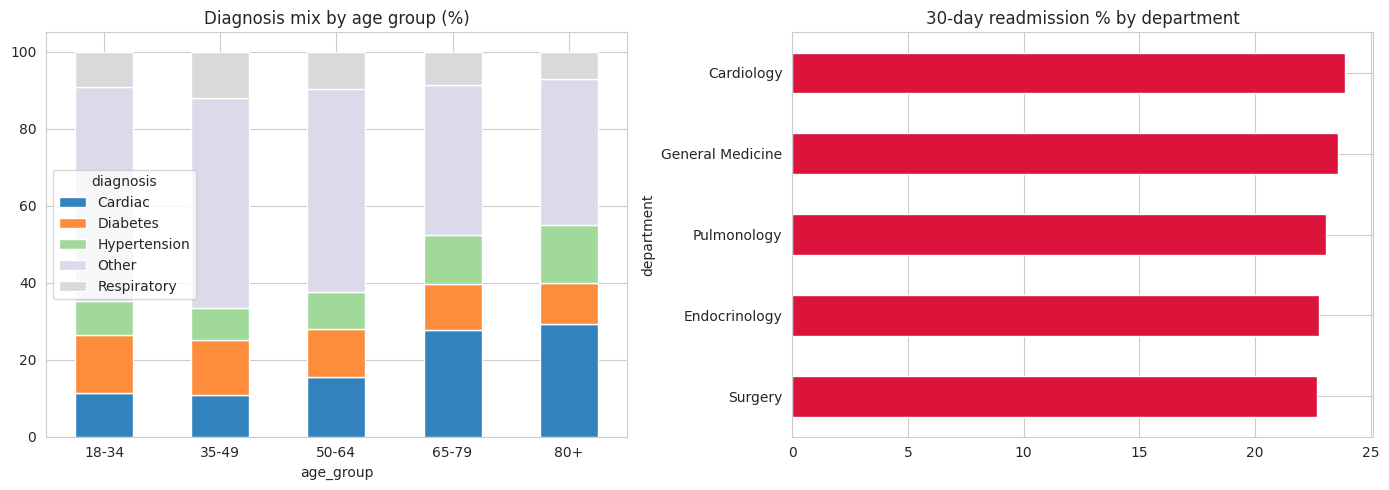

              mean  count
diagnosis                
Cardiac       34.7   1042
Diabetes      24.7    778
Respiratory   22.9    593
Hypertension  20.9    617
Other         19.5   2970


In [5]:
cond_age = pd.crosstab(patients["age_group"], patients["diagnosis"], normalize="index") * 100
print(cond_age.round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cond_age.plot(kind="bar", stacked=True, ax=ax[0], colormap="tab20c")
ax[0].set_title("Diagnosis mix by age group (%)")
ax[0].tick_params(axis="x", rotation=0)
dept_rate = patients.groupby("department")["readmit_30d"].mean().sort_values() * 100
overall_rate = patients["readmit_30d"].mean()
dept_n = patients.groupby("department").size()
dept_z = ((dept_rate / 100 - overall_rate) / np.sqrt(overall_rate * (1 - overall_rate) / dept_n)).round(2)
dept_real = bool(dept_z.abs().max() > 3)
print("How far each department is from the overall rate (z-score, above 3 or below -3 is a real difference):")
print(dept_z.sort_values())
if dept_real:
    dept_note = "Some departments differ clearly from the overall readmission rate."
else:
    dept_note = "Department readmission rates are all within normal random variation of the overall rate, so no department stands out."
print(dept_note)
dept_rate.plot(kind="barh", ax=ax[1], color="crimson")
ax[1].set_title("30-day readmission % by department")
plt.tight_layout()
plt.show()

diag_rate = patients.groupby("diagnosis")["readmit_30d"].agg(["mean", "count"])
diag_rate["mean"] = (diag_rate["mean"] * 100).round(1)
print(diag_rate.sort_values("mean", ascending=False))

## Step 6: Risk factors

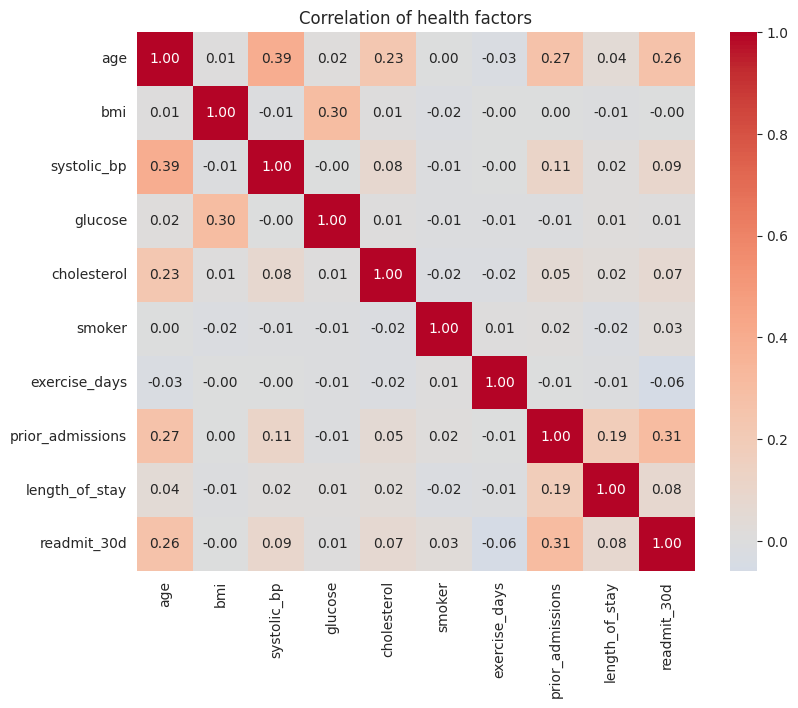

Readmission % by prior admissions:
prior_admissions
0    11.8
1    19.9
2    33.2
3    47.3
4    66.3
Name: readmit_30d, dtype: float64

Readmission % smoker vs non-smoker:
smoker
0    22.7
1    25.4
Name: readmit_30d, dtype: float64


In [6]:
num_cols = ["age", "bmi", "systolic_bp", "glucose", "cholesterol", "smoker", "exercise_days", "prior_admissions", "length_of_stay", "readmit_30d"]
corr = patients[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of health factors")
plt.show()

print("Readmission % by prior admissions:")
print((patients.groupby(patients["prior_admissions"].clip(upper=4))["readmit_30d"].mean() * 100).round(1))
print("\nReadmission % smoker vs non-smoker:")
print((patients.groupby("smoker")["readmit_30d"].mean() * 100).round(1))

## Step 7: Predict 30-day readmission

Logistic Regression AUC: 0.758
Gradient Boosting AUC: 0.733
Model used from here on: Logistic Regression (the one with the higher AUC)
The simpler model won, so a complicated model is not needed here.

Logistic Regression report (threshold 0.5):
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1151
           1       0.68      0.24      0.35       349

    accuracy                           0.80      1500
   macro avg       0.74      0.60      0.62      1500
weighted avg       0.78      0.80      0.76      1500

Recall for readmitted patients is low at 0.5, because most patients are not readmitted. That is why the next step ranks patients by risk instead of using one cut-off.


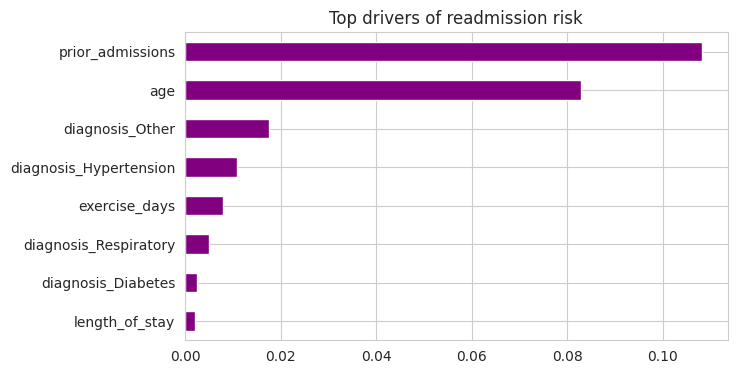

In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

X = pd.get_dummies(patients.drop(columns=["readmit_30d", "age_group"]), drop_first=True)
y = patients["readmit_30d"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000))])
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]

gb = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
gb_prob = gb.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_prob)
gb_auc = roc_auc_score(y_test, gb_prob)
print("Logistic Regression AUC:", round(lr_auc, 3))
print("Gradient Boosting AUC:", round(gb_auc, 3))
if lr_auc >= gb_auc:
    final_name, final_model, final_prob = "Logistic Regression", lr, lr_prob
else:
    final_name, final_model, final_prob = "Gradient Boosting", gb, gb_prob
print("Model used from here on:", final_name, "(the one with the higher AUC)")
if final_name == "Logistic Regression":
    print("The simpler model won, so a complicated model is not needed here.")
print("\n" + final_name + " report (threshold 0.5):")
print(classification_report(y_test, (final_prob > 0.5).astype(int)))
print("Recall for readmitted patients is low at 0.5, because most patients are not readmitted. That is why the next step ranks patients by risk instead of using one cut-off.")

perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=42)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(8)
imp.sort_values().plot(kind="barh", figsize=(7, 4), color="purple")
plt.title("Top drivers of readmission risk")
plt.show()

## Step 8: Risk tiers and lift
Lift tells how much better the model is than picking patients randomly for follow-up calls.

        patients  readmit_rate  avg_risk
decile                                  
1            150           3.3       5.7
2            150           6.7       8.3
3            150          12.7      10.9
4            150          11.3      13.6
5            150          17.3      16.6
6            150          25.3      20.1
7            150          21.3      24.7
8            150          34.0      30.6
9            150          40.0      40.0
10           150          60.7      59.8

Top decile readmission rate: 60.7 %
Lift in top decile: 2.61 x
Average predicted risk in the top decile: 59.8 % vs actual 60.7 %
        patients  actual_readmit_pct
tier                                
High         300                50.3
Medium       600                24.5
Low          600                 8.5


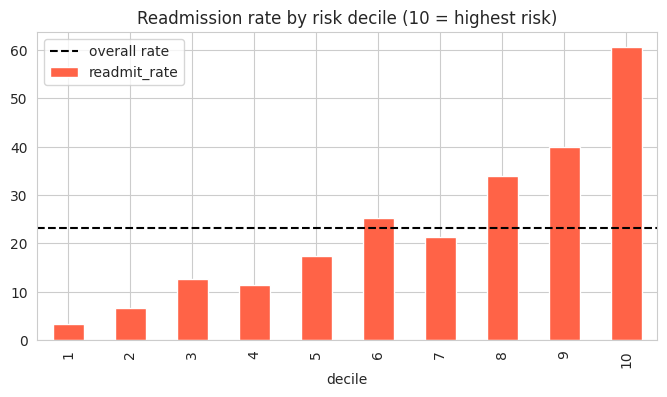

In [8]:
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["risk"] = final_prob
test_df["decile"] = pd.qcut(test_df["risk"].rank(method="first"), 10, labels=False) + 1

lift_table = test_df.groupby("decile").agg(patients=("actual", "count"), readmit_rate=("actual", "mean"), avg_risk=("risk", "mean"))
lift_table["readmit_rate"] = (lift_table["readmit_rate"] * 100).round(1)
lift_table["avg_risk"] = (lift_table["avg_risk"] * 100).round(1)
print(lift_table)

overall = test_df["actual"].mean()
top_decile_rate = test_df[test_df["decile"] == 10]["actual"].mean()
print("\nTop decile readmission rate:", round(top_decile_rate * 100, 1), "%")
print("Lift in top decile:", round(top_decile_rate / overall, 2), "x")
top_pred = test_df[test_df["decile"] == 10]["risk"].mean()
print("Average predicted risk in the top decile:", round(top_pred * 100, 1), "% vs actual", round(top_decile_rate * 100, 1), "%")
if top_pred - top_decile_rate > 0.05:
    print("The model slightly over-predicts risk for the highest-risk patients, so use the scores for ranking, not as exact probabilities.")

high_cut = test_df["risk"].quantile(0.8)
low_cut = test_df["risk"].quantile(0.4)
test_df["tier"] = test_df["risk"].apply(lambda r: "High" if r >= high_cut else ("Medium" if r >= low_cut else "Low"))
tiers = test_df.groupby("tier").agg(patients=("actual", "count"), actual_readmit_pct=("actual", lambda x: round(x.mean() * 100, 1)))
print(tiers.loc[["High", "Medium", "Low"]])

lift_table["readmit_rate"].plot(kind="bar", figsize=(8, 4), color="tomato")
plt.axhline(overall * 100, color="black", linestyle="--", label="overall rate")
plt.legend()
plt.title("Readmission rate by risk decile (10 = highest risk)")
plt.show()

## Step 9: AI population health brief (Groq)

In [9]:
text = f"""
Made-up patients analysed: {len(patients)}
Overall 30-day readmission rate: {patients['readmit_30d'].mean()*100:.1f}%
Department with the highest readmission rate: {dept_rate.index[-1]} at {dept_rate.iloc[-1]:.1f}% (this is the rate inside that department, not a share of all readmissions)
Department check: {dept_note}
Diagnosis with the highest readmission rate: {diag_rate['mean'].idxmax()} at {diag_rate['mean'].max():.1f}% (the rate inside that diagnosis group, not a share of all readmissions)
Model used: {final_name}, AUC {roc_auc_score(y_test, final_prob):.2f} (the other model scored {min(lr_auc, gb_auc):.2f})
Top decile lift: {top_decile_rate / overall:.2f}x, top decile readmission rate {top_decile_rate*100:.1f}%
Top model drivers (drop in AUC when the factor is shuffled): {imp.head(5).round(3).to_dict()}
Risk tiers (patients, actual readmit %): {tiers.to_dict('index')}
"""
brief = ask_llm("Write a short population health brief for a hospital care team: key findings, which patients to prioritise for follow-up calls, and 3 practical actions. Use only these numbers and do not calculate new ones. Do not suggest department-specific actions if the department check says no department stands out. Rates are rates inside a group, never say they are shares of all readmissions. The data is made up, say that once at the end. Do not give individual medical advice.\n" + text,
                system="You are a healthcare data analyst. Do not invent numbers.")
print(brief)

**Population‑Health Brief – Hospital Care Team**  

---

### Key Findings  

| Metric | Value |
|--------|-------|
| Patients analysed (total) | 6,000 |
| Overall 30‑day readmission rate | **23.3 %** |
| Highest department readmission rate* | Cardiology – **23.9 %** (within normal variation; no department‑specific focus warranted) |
| Highest diagnosis readmission rate | Cardiac – **34.7 %** |
| Predictive model | Logistic Regression (AUC = 0.76) – outperforms the alternative model (AUC = 0.73) |
| Top‑decile lift | **2.61 ×** (top‑decile readmission rate **60.7 %**) |
| Main model drivers (drop in AUC when shuffled) | 1. Prior admissions (0.108)  2. Age (0.083)  3. Diagnosis = Other (0.018)  4. Diagnosis = Hypertension (0.011)  5. Exercise days (0.008) |
| Risk‑tier performance | **High** – 300 patients, actual readmission **50.3 %**  | **Medium** – 600 patients, actual readmission **24.5 %**  | **Low** – 600 patients, actual readmission **8.5 %** |

\*Although Cardiology shows the nu

## Step 10: Key insights and export

In [10]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Overall 30-day readmission:", round(patients["readmit_30d"].mean() * 100, 1), "%")
print("2. Highest risk diagnosis:", diag_rate["mean"].idxmax(), "-", diag_rate["mean"].max(), "%")
print("3. Top model driver:", imp.index[0])
print("4. Model used:", final_name, "- AUC", round(roc_auc_score(y_test, final_prob), 3), "(Logistic Regression", round(lr_auc, 3), "vs Gradient Boosting", round(gb_auc, 3), ") and top decile lift", round(top_decile_rate / overall, 2), "x")
print("6. Department check:", dept_note)
print("7. All patients here are made up, so these numbers describe the method only")
print("5. Contacting the top 20% riskiest patients covers", round(test_df[test_df["tier"] == "High"]["actual"].sum() / test_df["actual"].sum() * 100, 1), "% of all readmissions")

patients_scored = patients.copy()
Xall = pd.get_dummies(patients_scored.drop(columns=["readmit_30d", "age_group"]), drop_first=True).reindex(columns=X.columns, fill_value=0)
patients_scored["risk_score"] = final_model.predict_proba(Xall)[:, 1]
patients_scored["risk_tier"] = patients_scored["risk_score"].apply(lambda r: "High" if r >= high_cut else ("Medium" if r >= low_cut else "Low"))
patients_scored.to_csv("healthinsight_patients_scored.csv", index=False)
lift_table.to_csv("healthinsight_lift_table.csv")
print("\nSaved healthinsight_patients_scored.csv and healthinsight_lift_table.csv")

KEY INSIGHTS (calculated from this run)
1. Overall 30-day readmission: 23.3 %
2. Highest risk diagnosis: Cardiac - 34.7 %
3. Top model driver: prior_admissions
4. Model used: Logistic Regression - AUC 0.758 (Logistic Regression 0.758 vs Gradient Boosting 0.733 ) and top decile lift 2.61 x
6. Department check: Department readmission rates are all within normal random variation of the overall rate, so no department stands out.
7. All patients here are made up, so these numbers describe the method only
5. Contacting the top 20% riskiest patients covers 43.3 % of all readmissions

Saved healthinsight_patients_scored.csv and healthinsight_lift_table.csv



---
Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)